In [21]:
import pandas as pd 
import numpy as np

# Load Dataset 
df = pd.read_csv(r"C:\Users\phxac\Downloads\UG Project\SMOTE_collegiate_athlete_injury_dataset.csv.arff.csv")


In [22]:
# Removing Coloumns to reduce noise 
df.drop(columns=['Athlete_ID'], inplace=True)
df.drop(columns=['Position'], inplace=True)

In [23]:
# Convert Catergial Gender to  
df['Gender'] = df['Gender'].replace({'Male': 0, 'Female': 1})

C:\Users\phxac\AppData\Local\Temp\ipykernel_3360\3350505798.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] = df['Gender'].replace({'Male': 0, 'Female': 1})


In [56]:
# Corelation matrix 
corr_matrix = df.corr()

print(corr_matrix["Injury_Indicator"].sort_values(ascending=False))
print(df['Injury_Indicator'].value_counts()) # Class Balance check 

Injury_Indicator            1.000000
ACL_Risk_Score              0.822055
Fatigue_Score               0.707621
Gender                      0.325216
Cluster                     0.280947
Training_Intensity          0.238415
Training_Hours_Per_Week     0.225905
Age                         0.102417
Height_cm                  -0.121297
Performance_Score          -0.143063
Team_Contribution_Score    -0.164711
Rest_Between_Events_Days   -0.243320
Weight_kg                  -0.380555
Match_Count_Per_Week       -0.487817
Recovery_Days_Per_Week     -0.664479
Load_Balance_Score         -0.840009
Name: Injury_Indicator, dtype: float64
Injury_Indicator
0    186
1    182
Name: count, dtype: int64


In [ ]:
### Decision Trees ###

In [25]:
# necessary Decision tree libraries
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [26]:
# Define features (X) and target (y)
X = df.drop(columns=['Injury_Indicator'])
y = df['Injury_Indicator']

In [27]:
# Spliting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# Initialize and train the Decision Tree Classifier
# Prune Decision Tree
model = DecisionTreeClassifier(max_depth=5, 
                               min_samples_leaf=4,
                               random_state=42
                              ) 
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]

' model = RandomForestClassifier(n_estimators=100, random_state=42)\nmodel.fit(X, y)\n\nmodel.predict_proba(X_train)'

In [29]:
# Making predictions on the test set
y_pred = model.predict(X_test)

In [30]:
# Model Evalutation 
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9459459459459459
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        40
           1       0.94      0.94      0.94        34

    accuracy                           0.95        74
   macro avg       0.95      0.95      0.95        74
weighted avg       0.95      0.95      0.95        74



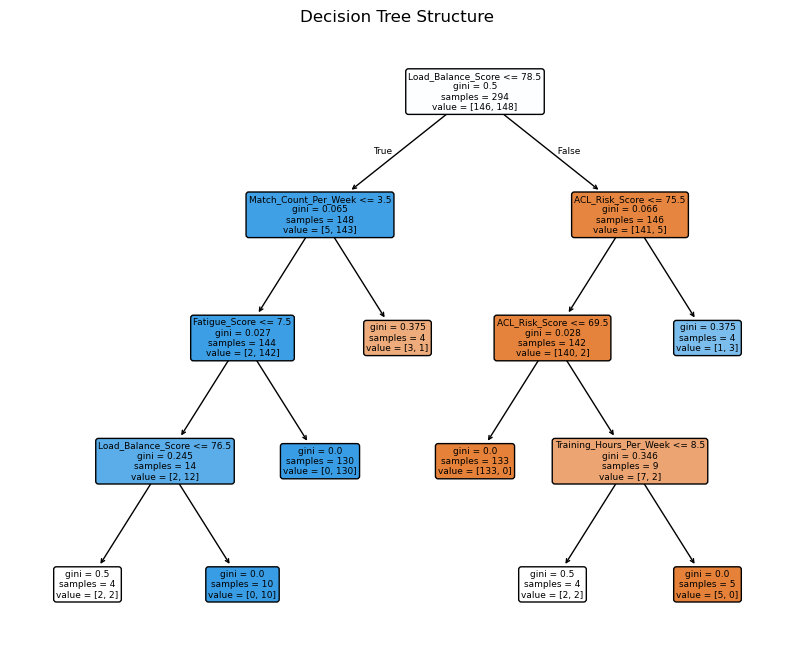

In [54]:
# Plot decision tree
plt.figure(figsize=(10, 8))
plot_tree(model, feature_names=X.columns, rounded= True, filled=True)
plt.title("Decision Tree Structure")
plt.show()


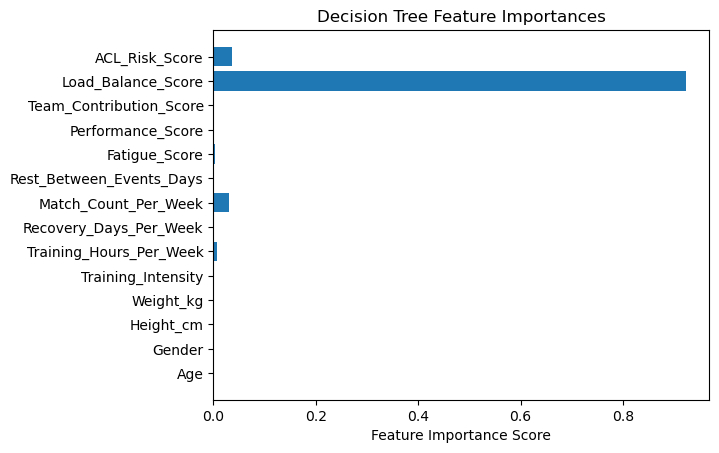

In [32]:
importances = model.feature_importances_
plt.barh(X.columns, importances)
plt.xlabel('Feature Importance Score')
plt.title('Decision Tree Feature Importances')
plt.show()

In [33]:
# Get predicted probabilities from Decision tree trained model
y_proba = model.predict_proba(X_test)[:, 1]  # probability of class 1 (injury)

# Empty list to store risk levels
injury_likelihood = []

# Loop through each probability and classify likelihood
for prob in y_proba:
    if prob < 0.25:
        injury_likelihood.append('Low')
    elif prob < 0.5:
        injury_likelihood.append('Medium')
    elif prob < 0.75:
        injury_likelihood.append('High')
    else:
        injury_likelihood.append('Very High')

#  DataFrame for reporting
results_df = X_test.copy()  # copy the test features
results_df['Actual_Injury'] = y_test.values  # add actual labels
results_df['Predicted_Probability'] = y_proba  
results_df['Predicted_Likelihood'] = injury_likelihood  

# Step 5: Display the results
print(results_df[['Actual_Injury', 'Predicted_Probability', 'Predicted_Likelihood']].head(15))


     Actual_Injury  Predicted_Probability Predicted_Likelihood
165              0                   0.00                  Low
33               0                   0.00                  Low
15               0                   0.00                  Low
312              1                   1.00            Very High
57               0                   0.00                  Low
219              1                   1.00            Very High
76               0                   0.00                  Low
119              1                   0.25               Medium
153              0                   0.00                  Low
126              0                   0.00                  Low
229              1                   1.00            Very High
39               0                   0.75            Very High
152              0                   0.00                  Low
55               0                   0.00                  Low
137              0                   0.00              

In [16]:
import joblib
# Save the trained model
joblib.dump(model, 'model.pkl')


['model.pkl']

In [34]:
### K MEANS ###

In [35]:
# Import necessary libraries for K clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [36]:
# Prepare the data (reusing data from Decision Tree)
X_cluster = X.copy()

In [39]:
# Find the optimal number of clusters using the Elbow method
inertia = []
silhouette_scores = range(2, 11)

for k in silhouette_scores:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

\\?\C:\Users\phxac\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
\\?\C:\Users\phxac\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
\\?\C:\Users\phxac\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
\\?\C:\Users\

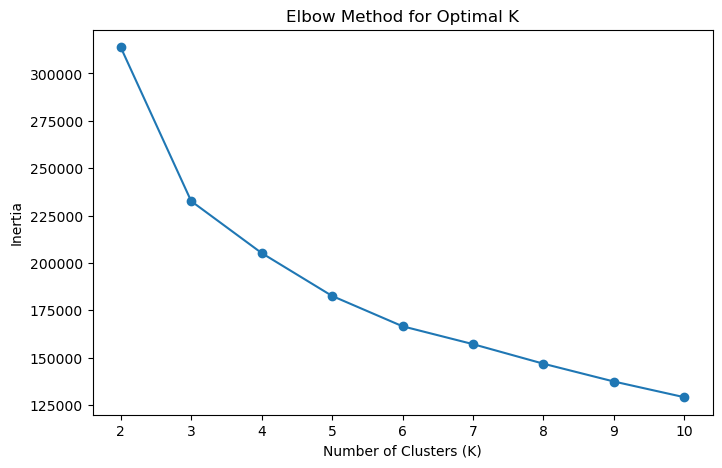

In [40]:
# Plot the Elbow graph
plt.figure(figsize=(8, 5))
plt.plot(silhouette_scores, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

In [41]:
# Choose the optimal K (you can choose based on the elbow point)
optimal_k = 4  # Change this based on the graph
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_cluster)

\\?\C:\Users\phxac\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [42]:
# Add cluster labels to DataFrame
df['Cluster'] = cluster_labels

In [43]:
# CLuster evalutation
silhouette_avg = silhouette_score(X_cluster, cluster_labels)
print(f"Silhouette Score for K={optimal_k}: {silhouette_avg:.2f}")

Silhouette Score for K=4: 0.34


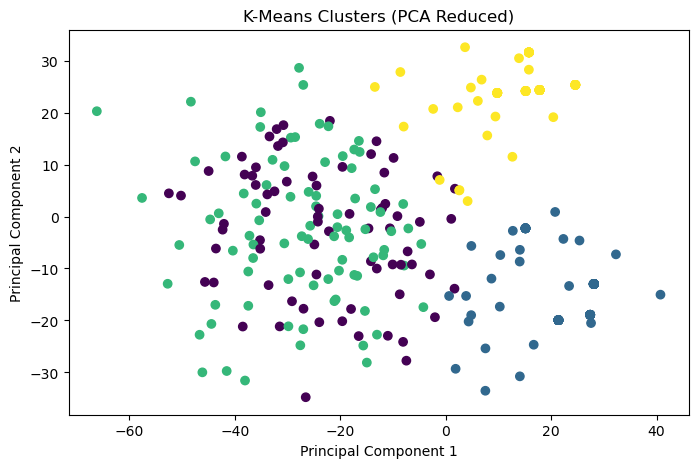

In [44]:
# Visualize clusters (using two principal components if there are many features)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis')
plt.title("K-Means Clusters (PCA Reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [45]:
# Cluster Summary CSV FILE 

df_clustered = pd.DataFrame(X_cluster)
df_clustered['Cluster'] = cluster_labels

cluster_summary = df_clustered.groupby('Cluster').mean()

cluster_summary.to_csv('cluster_summary.csv')

In [72]:
# Princpical Component Analsis CSV FILE 
df_pca_clusters = pd.DataFrame({
    'PCA1' : X_pca[:, 0],
    'PCA2' : X_pca[:, 1],
    'Cluster': cluster_labels
})

df_pca_clusters.to_csv('pca_clusters.csv', index=False)